In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, desc, avg, regexp_replace
import matplotlib.pyplot as plt
import pandas as pd

#(pour Kerberos plus bas)
import os 
import subprocess

## PARTIE 3 (BONUS) : Test du Kerberos

Installation du client Kerberos (Commande Linux via Python) 
On installe les outils pour parler au serveur de sécurité

Non fonctionnel (donc installation manuelle, CF. rapport)

Configuration du fichier krb5.conf (L'annuaire)
On dit au client où se trouve le serveur Kerberos (notre conteneur 'kerberos')

In [2]:
krb5_config = """
[libdefaults]
    default_realm = HADOOP.DOCKER
    dns_lookup_realm = false
    dns_lookup_kdc = false

[realms]
    HADOOP.DOCKER = {
        kdc = kerberos:88
        admin_server = kerberos:749
    }

[domain_realm]
    .hadoop.docker = HADOOP.DOCKER
    hadoop.docker = HADOOP.DOCKER
"""

# On écrit cette configuration dans le fichier système
with open("/etc/krb5.conf", "w") as f:
    f.write(krb5_config)
print("Configuration Kerberos (/etc/krb5.conf) mise à jour.")

#Authentification (Le test final)
#On essaie d'obtenir un ticket pour l'utilisateur 'camil'

# La commande kinit demande un mot de passe.
# Ici on utilise une astuce pour lui donner le mot de passe 'camil' automatiquement
print("-" * 30)
print("Tentative d'obtention du ticket (TGT)...")
cmd_auth = "echo 'camil' | kinit camil" 

retour_auth = os.system(cmd_auth)

if retour_auth == 0:
    print("✅ SUCCÈS : Authentification Kerberos réussie !")
    print("Voici votre Ticket (Preuve d'identité) :")
    print("-" * 20)
    # On affiche le contenu du ticket
    resultat = subprocess.getoutput("klist")
    print(resultat)
else:
    print(f"❌ ÉCHEC : Code erreur {retour_auth}. Vérifiez que l'utilisateur 'camil' existe bien.")

Configuration Kerberos (/etc/krb5.conf) mise à jour.
------------------------------
Tentative d'obtention du ticket (TGT)...
✅ SUCCÈS : Authentification Kerberos réussie !
Voici votre Ticket (Preuve d'identité) :
--------------------
Ticket cache: FILE:/tmp/krb5cc_1000
Default principal: camil@HADOOP.DOCKER

Valid starting       Expires              Service principal
01/11/2026 12:33:21  01/12/2026 00:33:21  krbtgt/HADOOP.DOCKER@HADOOP.DOCKER
	renew until 01/12/2026 12:33:21


## Configuration 

### Test avec et sans ticket : 

In [3]:
# !kdestroy
!klist
# Doit afficher : "No credentials cache found"

Ticket cache: FILE:/tmp/krb5cc_1000
Default principal: camil@HADOOP.DOCKER

Valid starting       Expires              Service principal
01/11/2026 12:33:21  01/12/2026 00:33:21  krbtgt/HADOOP.DOCKER@HADOOP.DOCKER
	renew until 01/12/2026 12:33:21


Cette simulation n'empêche toujours pas le Fallback to Simple Auth

In [4]:
# !echo 'camil' | kinit camil

In [5]:
# Démarrage du cluster Spark (ancienne version)
# spark = SparkSession.builder.appName("AnalyseFilms").getOrCreate()

# Démarrage du cluster Spark (nouvelle version)
# spark = SparkSession.builder \
#     .appName("AnalyseFilms_Kerberos") \
#     .master("local[*]") \
#     .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:9000") \
#     .getOrCreate()

# print("Cluster Spark démarré !")

# Démarrage du cluster Spark en mode STRICT Kerberos
# On force le client à utiliser Kerberos
spark = SparkSession.builder \
    .appName("AnalyseFilms_Kerberos") \
    .master("local[*]") \
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:9000") \
    .config("spark.hadoop.hadoop.security.authentication", "kerberos") \
    .config("spark.hadoop.ipc.client.fallback-to-simple-auth-allowed", "false") \
    .getOrCreate()

print("Cluster Spark démarré en mode SÉCURISÉ !")

Cluster Spark démarré en mode SÉCURISÉ !


### Suite de la configuration

In [6]:
# On charge le fichier 'films.csv' situé dans le dossier partagé
# df = spark.read.csv("films.csv", header=True, inferSchema=True)

# Lecture du fichier csv
# Note : On utilise file:/// pour lire le fichier local monté dans le volume
csv_path = "file:///home/jovyan/work/films.csv"

try:
    df = spark.read.csv(csv_path, header=True, inferSchema=True)
    print(f"Fichier chargé. {df.count()} lignes.")
    df.show(5)
except Exception as e:
    print("Erreur de chargement :", e)

Fichier chargé. 1000 lignes.
+--------------------+--------------------+-------------+-----------+-------+--------------------+-----------+--------------------+----------+--------------------+--------------+--------------+-------------+--------------+-----------+-----------+
|         Poster_Link|        Series_Title|Released_Year|Certificate|Runtime|               Genre|IMDB_Rating|            Overview|Meta_score|            Director|         Star1|         Star2|        Star3|         Star4|No_of_Votes|      Gross|
+--------------------+--------------------+-------------+-----------+-------+--------------------+-----------+--------------------+----------+--------------------+--------------+--------------+-------------+--------------+-----------+-----------+
|https://m.media-a...|The Shawshank Red...|         1994|          A|142 min|               Drama|        9.3|Two imprisoned me...|        80|      Frank Darabont|   Tim Robbins|Morgan Freeman|   Bob Gunton|William Sadler|    2343

In [7]:
df.columns

['Poster_Link',
 'Series_Title',
 'Released_Year',
 'Certificate',
 'Runtime',
 'Genre',
 'IMDB_Rating',
 'Overview',
 'Meta_score',
 'Director',
 'Star1',
 'Star2',
 'Star3',
 'Star4',
 'No_of_Votes',
 'Gross']

In [8]:
# Supprimer les colonnes inutiles
columns_to_drop = ["Poster_Link", "Overview", "Certificate", "Meta_score"]
df_clean = df.drop(*columns_to_drop)

In [9]:
# Nettoyer la colonne recette (Gross) détéctée comme texte à cause des virgules : 
df_clean = df_clean.withColumn("Gross", regexp_replace(col("Gross"), ",", "").cast("double"))

In [10]:
# Supprimer les lignes vides
df = df.dropna()

In [11]:
print("Aperçu des données :")
df.select("Series_Title", "Released_Year", "IMDB_Rating", "Genre", "Gross").show(5)

Aperçu des données :
+--------------------+-------------+-----------+--------------------+-----------+
|        Series_Title|Released_Year|IMDB_Rating|               Genre|      Gross|
+--------------------+-------------+-----------+--------------------+-----------+
|The Shawshank Red...|         1994|        9.3|               Drama| 28,341,469|
|       The Godfather|         1972|        9.2|        Crime, Drama|134,966,411|
|     The Dark Knight|         2008|        9.0|Action, Crime, Drama|534,858,444|
|The Godfather: Pa...|         1974|        9.0|        Crime, Drama| 57,300,000|
|        12 Angry Men|         1957|        9.0|        Crime, Drama|  4,360,000|
+--------------------+-------------+-----------+--------------------+-----------+
only showing top 5 rows



## Analyse 1 : Top 10 des réalisateurs et nombre de films dans le top 1000

In [12]:
print("--- Top 10 des Réalisateurs ---")

top_directors = df.groupBy("Director").count().orderBy(desc("count")).limit(10)

top_directors.show()

--- Top 10 des Réalisateurs ---
+-----------------+-----+
|         Director|count|
+-----------------+-----+
| Steven Spielberg|   12|
|  Martin Scorsese|   10|
| Alfred Hitchcock|    9|
|   Clint Eastwood|    8|
|    David Fincher|    8|
|Christopher Nolan|    8|
|Quentin Tarantino|    8|
|      Woody Allen|    7|
|       Rob Reiner|    7|
|   Hayao Miyazaki|    7|
+-----------------+-----+



#### Visualisation 1

In [13]:
pdf_directors = top_directors.toPandas()

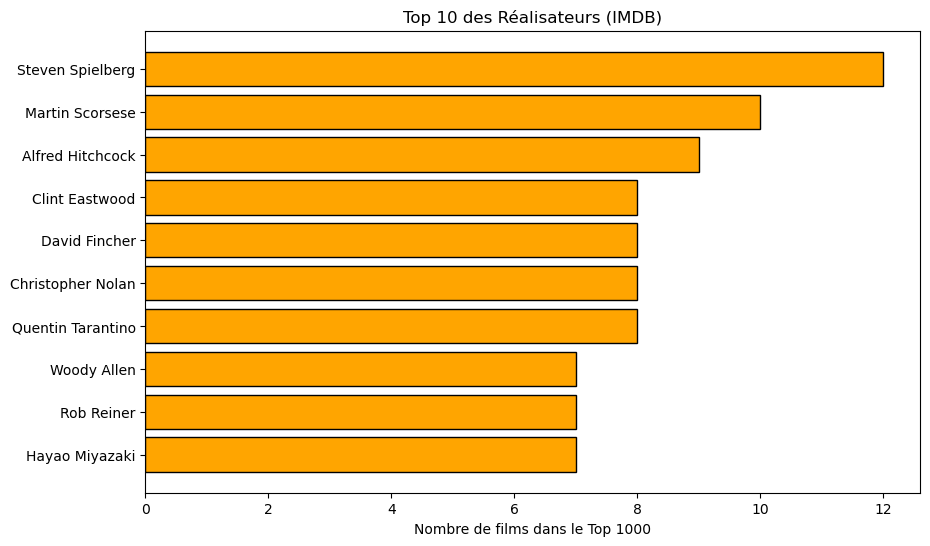

In [14]:
plt.figure(figsize=(10, 6))
plt.barh(pdf_directors['Director'], pdf_directors['count'], color='orange', edgecolor='black')
plt.xlabel('Nombre de films dans le Top 1000')
plt.title('Top 10 des Réalisateurs (IMDB)')
plt.gca().invert_yaxis() # Pour avoir le premier en haut
plt.show()

## Analyse 2 : Top 10 des notes moyennes par genre

In [15]:
print("--- Note moyenne par Genre (Top 10) ---")

# Même si un film peut avoir plusieurs genre, j'ai décidé de simplifier la requête initiale
top_genres = df.groupBy("Genre").agg(avg("IMDB_Rating").alias("Note_Moyenne")).orderBy(desc("Note_Moyenne")).limit(10)

top_genres.show()

--- Note moyenne par Genre (Top 10) ---
+--------------------+-----------------+
|               Genre|     Note_Moyenne|
+--------------------+-----------------+
|Crime, Mystery, T...|              8.5|
|      Horror, Sci-Fi|              8.4|
|       Drama, Horror|              8.4|
|      Action, Sci-Fi|              8.4|
| Drama, Mystery, War|8.350000000000001|
|             Western|             8.35|
|Comedy, Musical, ...|              8.3|
|Crime, Drama, Sci-Fi|              8.3|
|Mystery, Romance,...|              8.3|
|Adventure, Myster...|              8.3|
+--------------------+-----------------+



#### Visualisation 2

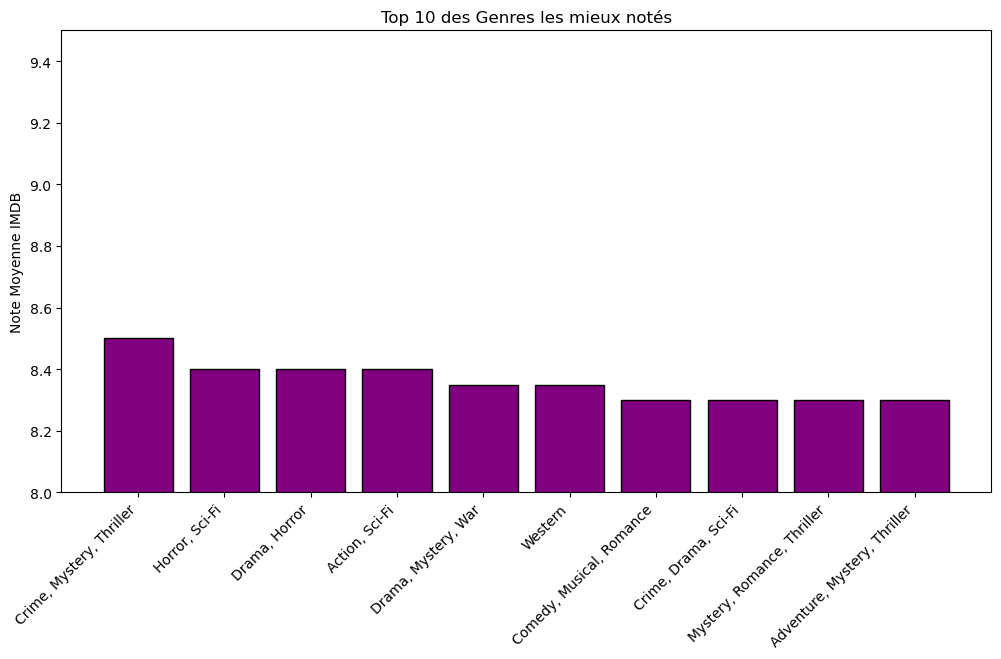

In [16]:
pdf_genres = top_genres.toPandas()

plt.figure(figsize=(12, 6))
plt.bar(pdf_genres['Genre'], pdf_genres['Note_Moyenne'], color='purple', edgecolor='black')
plt.xticks(rotation=45, ha='right') # On penche les textes pour lire
plt.ylim(8, 9.5) # On zoom l'échelle entre 8 et 9.5 pour mieux voir les écarts
plt.title('Top 10 des Genres les mieux notés')
plt.ylabel('Note Moyenne IMDB')
plt.show()

## Analyse 3 : Combien de films de ce Top 1000 ont été produits chaque année ?

In [17]:
# On groupe par année et on compte
films_par_annee = df_clean.groupBy("Released_Year").count().orderBy("Released_Year") # Important de trier par année chrono

# Conversion en Pandas pour le graphique
pdf_time = films_par_annee.toPandas()

#### Visualisation 3

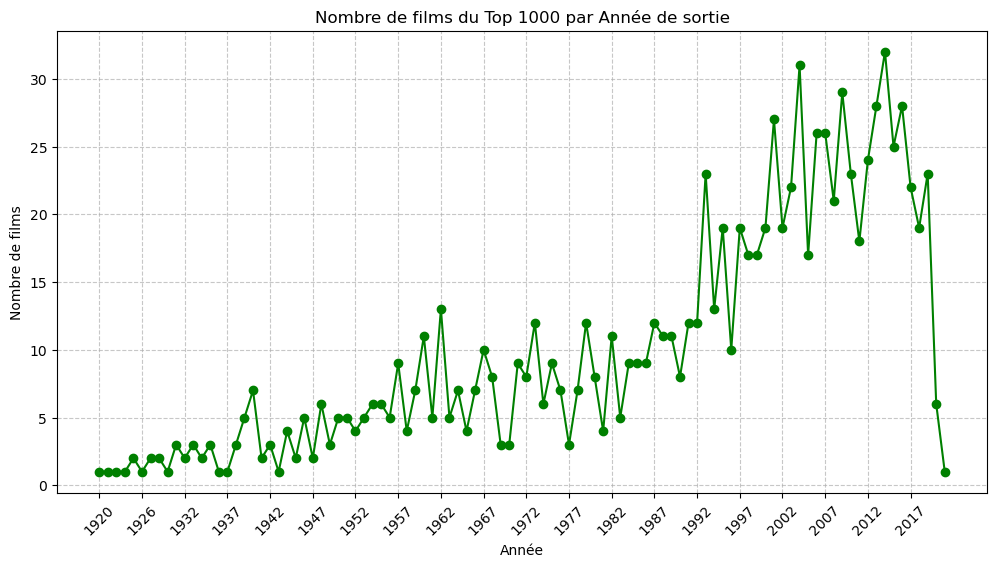

In [18]:
# Création du graphique (Courbe)
plt.figure(figsize=(12, 6))
plt.plot(pdf_time['Released_Year'], pdf_time['count'], color='green', marker='o', linestyle='-')

# Pour la lisibilité
plt.xticks(pdf_time['Released_Year'][::5], rotation=45)

plt.title('Nombre de films du Top 1000 par Année de sortie')
plt.xlabel('Année')
plt.ylabel('Nombre de films')
plt.grid(True, linestyle='--', alpha=0.7) # Ajoute une grille pour la lisibilité
plt.show()

## Analyse 4 : Quels sont les films qui ont rapporté le plus d'argent au Box Office ?

In [19]:
top_gross = df_clean.select("Series_Title", "Gross").orderBy(desc("Gross")).limit(10)

top_gross.show() # Affiche les chiffres bruts

# Visualisation
pdf_gross = top_gross.toPandas()

+--------------------+------------+
|        Series_Title|       Gross|
+--------------------+------------+
|Star Wars: Episod...|9.36662225E8|
|   Avengers: Endgame|   8.58373E8|
|              Avatar|7.60507625E8|
|Avengers: Infinit...|6.78815482E8|
|             Titanic|6.59325379E8|
|        The Avengers|6.23279547E8|
|       Incredibles 2|6.08581744E8|
|     The Dark Knight|5.34858444E8|
|           Rogue One|5.32177324E8|
|The Dark Knight R...|4.48139099E8|
+--------------------+------------+



#### Visualisation 4

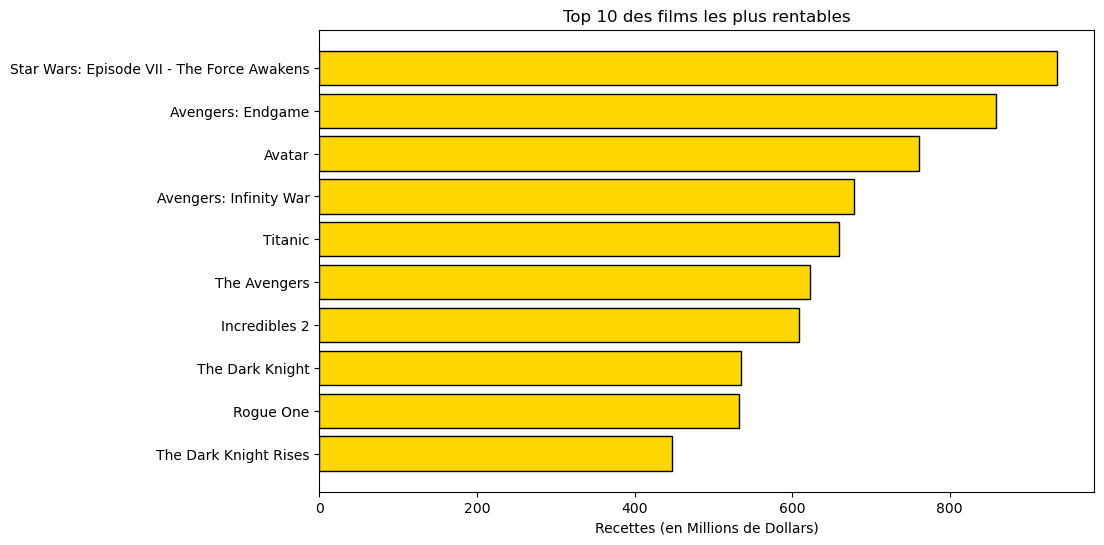

In [20]:
plt.figure(figsize=(10, 6))
# On divise par 1 million pour que ce soit lisible sur l'axe
plt.barh(pdf_gross['Series_Title'], pdf_gross['Gross'] / 1000000, color='gold', edgecolor='black')

plt.xlabel('Recettes (en Millions de Dollars)')
plt.title('Top 10 des films les plus rentables')
plt.gca().invert_yaxis() # Le premier en haut
plt.show()

In [21]:
import time

## PARTIE 3 (BONUS) : CALCUL D'IMPACT ÉCOLOGIQUE

Pour les constantes, nous sommes parti des caractéristiques de l'ordinateur de Camille (Victus 15FB) : 

Batterie Li-ion polymère 3 cellules 
52,5 Wh


Type d'alimentation electrique avec adaptateur secteur 120 W
 

Sources référence carbone : EcoInfo CNRS, GreenIT.fr

In [22]:
PUISSANCE_CHARGEUR_MAX = 120.0  # Mon adaptateur 120 W
BATTERIE_CAPACITE_WH = 52.5     # Ma batterie 52.5 Wh
FACTEUR_CHARGE_CPU = 0.65       # Estimation : Docker + Spark utilisent ~65% de la puissance max
MIX_CO2_FRANCE_G_KWH = 57.0     # En France (Source: EcoInfo / RTE)

# Estimation du temps passé 
DUREE_SESSION_HEURES = 16.0      

def calculer_impact_reel(puissance_max, facteur, heures, mix_co2):
    # Puissance moyenne utilisée = Max * Facteur d'utilisation
    puissance_moyenne = puissance_max * facteur
    
    # Consommation en kWh
    conso_kwh = (puissance_moyenne * heures) / 1000
    
    # Impact CO2
    impact_g_co2 = conso_kwh * mix_co2
    
    return puissance_moyenne, conso_kwh, impact_g_co2

# 2. Calcul
p_moy, kwh, co2 = calculer_impact_reel(PUISSANCE_CHARGEUR_MAX, FACTEUR_CHARGE_CPU, DUREE_SESSION_HEURES, MIX_CO2_FRANCE_G_KWH)

# 3. Affichage professionnel pour le PDF
print(f"--- RAPPORT D'IMPACT ÉCOLOGIQUE (Données Matérielles) ---")
print(f"Matériel : PC Portable avec alimentation {int(PUISSANCE_CHARGEUR_MAX)}W")
print(f"Batterie : Li-ion polymère {BATTERIE_CAPACITE_WH} Wh")
print(f"Charge de travail : Cluster Hadoop/Spark (Estimation charge : {int(FACTEUR_CHARGE_CPU*100)}%)")
print(f"Durée du traitement : {DUREE_SESSION_HEURES} Heures")
print(f"-"*50)
print(f"Puissance moyenne estimée : {p_moy:.1f} Watts")
print(f"Consommation Électrique   : {kwh:.4f} kWh")
print(f"Empreinte Carbone         : {co2:.2f} gCO2e")
print(f"-"*50)
print("Méthodologie : Calcul basé sur la puissance de l'adaptateur secteur pondérée")
print("par l'usage CPU/RAM intensif des conteneurs Docker.")

--- RAPPORT D'IMPACT ÉCOLOGIQUE (Données Matérielles) ---
Matériel : PC Portable avec alimentation 120W
Batterie : Li-ion polymère 52.5 Wh
Charge de travail : Cluster Hadoop/Spark (Estimation charge : 65%)
Durée du traitement : 16.0 Heures
--------------------------------------------------
Puissance moyenne estimée : 78.0 Watts
Consommation Électrique   : 1.2480 kWh
Empreinte Carbone         : 71.14 gCO2e
--------------------------------------------------
Méthodologie : Calcul basé sur la puissance de l'adaptateur secteur pondérée
par l'usage CPU/RAM intensif des conteneurs Docker.
